# Testu erauzketaren emaitzen analisia

Notebook honen helburua `corpus_erauzketa.tsv` fitxategitik testu erauzketaren emaitza kuantitatibo nagusiak ateratzea da.

Aztertuko diren neurri nagusiak:

- **Parte-hartzeak**: `Speech_id` bidez identifikatutako diskurtso/interbentzio kopurua.
- **Paragrafoak edo testu-zatiak**: `Speech_id` + `Text_id` pareen kopurua.
- **Hizkuntza bakoitzeko banaketa**: paragrafoak, parte-hartzeak, hitzak eta entitateak.
- **Entitate izendunak**: guztizko kopurua, entitate bakarrak, etiketa motak eta hizkuntzaren araberako banaketa.


## 1. Konfigurazioa eta fitxategia kargatzea

Jarri notebook hau `corpus_erauzketa.tsv` fitxategiaren karpeta berean. Bestela, aldatu beheko `DATA_PATH` aldagaia fitxategiaren kokapen zehatza adierazteko.


In [1]:
from pathlib import Path
import json
import ast
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

DATA_PATH = Path("corpus_erauzketa.tsv")
OUTPUT_DIR = Path("emaitzak_testu_erauzketa")
OUTPUT_DIR.mkdir(exist_ok=True)

if not DATA_PATH.exists():
    candidates = list(Path.cwd().glob("**/corpus_erauzketa.tsv"))
    if candidates:
        DATA_PATH = candidates[0]
    else:
        raise FileNotFoundError(
            "Ez da corpus_erauzketa.tsv aurkitu. Jarri fitxategia notebookaren karpeta berean "
            "edo aldatu DATA_PATH aldagaia."
        )

print(f"Erabilitako fitxategia: {DATA_PATH.resolve()}")


Erabilitako fitxategia: /home/hsanz004/Hodei_GRaL/testu_erauzketa/corpus_erauzketa.tsv


In [2]:
df = pd.read_csv(DATA_PATH, sep="\t", encoding="utf-8", dtype={"Speech_id": "string", "Text_id": "string"})

# Zutabe izenetan hasiera/amaierako hutsuneak baleude kentzeko.
df.columns = [c.strip() for c in df.columns]

# Espero diren zutabeak.
expected_cols = [
    "Date", "Speech_id", "Text_id", "Speaker", "Birth", "Gender", "Party",
    "Language", "Text", "Lemmas", "Entities"
]
missing = [c for c in expected_cols if c not in df.columns]
if missing:
    raise ValueError(f"Zutabe hauek falta dira TSV fitxategian: {missing}")

# Datak eta testu-eremuak normalizatu.
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
for col in ["Speaker", "Gender", "Party", "Language", "Text", "Lemmas", "Entities"]:
    df[col] = df[col].fillna("").astype(str).str.strip()

print(f"Dimentsioak: {df.shape[0]:,} errenkada x {df.shape[1]:,} zutabe".replace(",", "."))
display(df.head(3))


Dimentsioak: 106.309 errenkada x 11 zutabe


/tmp/ipykernel_3177816/3904987323.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH, sep="\t", encoding="utf-8", dtype={"Speech_id": "string", "Text_id": "string"})


,Date,Speech_id,Text_id,Speaker,Birth,Gender,Party,Language,Text,Lemmas,Entities
0,2012-11-27,0,0,Tejeria Otermin LEHENDAKARIA,1971.0,E,EAJ,eu,"Erregelamenduaren 6.2.artikuluan jasotakoari jarraituz, legebiltzar taldeetako bina kidek osatuko dute Bateraezintas...",erregelamendu 62artikulu jas jarraitu legebiltzar talde bin kide osatu *edun bateraezintasun behin-behine batzorde l...,"[{""text"": ""Bateraezintasunen Behin-Behineko Batzordea"", ""label"": ""ORG""}, {""text"": ""Euzko Abertzaleak"", ""label"": ""ORG..."
1,2012-11-27,0,1,Tejeria Otermin LEHENDAKARIA,1971.0,E,EAJ,eu,"Horri buruz inork zerbait esateko balu, Legebiltzarra ados badago, Bateraezintasunen Behin-Behineko Batzordea onartu...",hori buruz inor zerbait esan *edun legebiltzar a ados egon bateraezintasun behin-behineko batzorde onartu egin izan ...,"[{""text"": ""Legebiltzarra"", ""label"": ""ORG""}, {""text"": ""Bateraezintasunen Behin-Behineko Batzordea"", ""label"": ""ORG""}, ..."
2,2012-11-27,0,2,Tejeria Otermin LEHENDAKARIA,1971.0,E,EAJ,eu,"Bai esan, mesedez, berriak zaretenak, gelditu nahi duzuenak orain (joango?) dela, bueno, erakutsiko zaizuela bozketa...",bai esan mesede berri izark gelditu nahi aan orain joan izan bueno erakutsi ian bozketa hemen aurrera nola egin *due...,[]


## 2. Oinarrizko egiaztapenak

Atal honetan bikoiztuak eta gakoen koherentzia begiratzen dira. Horrek bereziki laguntzen du `Speech_id` benetan parte-hartze bakar gisa erabil daitekeen egiaztatzeko.


In [3]:
# Speech_id globalki bakarra den ala ez aztertu.
speech_id_profile = (
    df.groupby("Speech_id", dropna=False)
      .agg(
          n_dates=("Date", "nunique"),
          n_speakers=("Speaker", "nunique"),
          n_languages=("Language", "nunique"),
          n_rows=("Text_id", "size")
      )
      .reset_index()
)

speech_id_reused = speech_id_profile.query("n_dates > 1 or n_speakers > 1")

if len(speech_id_reused) > 0:
    df["speech_key"] = (
        df["Date"].dt.strftime("%Y-%m-%d").fillna("data_gabe")
        + "__" + df["Speech_id"].astype(str)
        + "__" + df["Speaker"].fillna("hizlari_gabe")
    )
    print("OHARRA: Speech_id batzuk data edo hizlari desberdinetan agertzen dira. Gako konposatua erabiliko da: Date + Speech_id + Speaker.")
else:
    df["speech_key"] = df["Speech_id"].astype(str)
    print("Speech_id balioa parte-hartzeen gako nagusi gisa erabiliko da.")

# Paragrafo/testu-zati gakoa.
df["paragraph_key"] = df["speech_key"].astype(str) + "__" + df["Text_id"].astype(str)

n_duplicate_paragraphs = df.duplicated("paragraph_key").sum()
print(f"Bikoiztutako paragrafo-gakoak: {n_duplicate_paragraphs:,}".replace(",", "."))

if n_duplicate_paragraphs > 0:
    display(df.loc[df.duplicated("paragraph_key", keep=False), ["Date", "Speech_id", "Text_id", "Speaker", "Language", "Text"]].head(10))


OHARRA: Speech_id batzuk data edo hizlari desberdinetan agertzen dira. Gako konposatua erabiliko da: Date + Speech_id + Speaker.
Bikoiztutako paragrafo-gakoak: 0


## 3. Entitateen eremua prestatzea


In [4]:
def parse_entities(value):
    """Entities zutabea zerrenda estandar batera bihurtzen du."""
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return value
    text = str(value).strip()
    if text in {"", "[]", "nan", "None"}:
        return []
    try:
        parsed = json.loads(text)
    except json.JSONDecodeError:
        try:
            parsed = ast.literal_eval(text)
        except (ValueError, SyntaxError):
            return []
    if not isinstance(parsed, list):
        return []
    clean = []
    for item in parsed:
        if isinstance(item, dict):
            ent_text = str(item.get("text", "")).strip()
            ent_label = str(item.get("label", "")).strip()
            if ent_text:
                clean.append({"text": ent_text, "label": ent_label if ent_label else "LABEL_GABE"})
    return clean


def normalize_entity_text(text):
    """Entitateak modu bateratuagoan zenbatzeko normalizazio arina."""
    text = str(text).strip().lower()
    text = re.sub(r"\s+", " ", text)
    return text


df["entities_list"] = df["Entities"].apply(parse_entities)
df["n_entities"] = df["entities_list"].apply(len)
df["n_words"] = df["Text"].apply(lambda x: len(str(x).split()))
df["n_lemmas"] = df["Lemmas"].apply(lambda x: len(str(x).split()))

entity_rows = []
for idx, row in df.iterrows():
    for ent in row["entities_list"]:
        entity_rows.append({
            "row_index": idx,
            "Date": row["Date"],
            "speech_key": row["speech_key"],
            "paragraph_key": row["paragraph_key"],
            "Speech_id": row["Speech_id"],
            "Text_id": row["Text_id"],
            "Speaker": row["Speaker"],
            "Party": row["Party"],
            "Language": row["Language"],
            "entity_text": ent.get("text", ""),
            "entity_label": ent.get("label", "LABEL_GABE"),
            "entity_text_norm": normalize_entity_text(ent.get("text", "")),
        })

ent_df = pd.DataFrame(entity_rows)

print(f"Entitate agerraldiak guztira: {len(ent_df):,}".replace(",", "."))
if len(ent_df) > 0:
    display(ent_df.head(10))
else:
    print("Ez da entitaterik aurkitu Entities zutabean.")


Entitate agerraldiak guztira: 524.395


,row_index,Date,speech_key,paragraph_key,Speech_id,Text_id,Speaker,Party,Language,entity_text,entity_label,entity_text_norm
0,0,2012-11-27,2012-11-27__0__Tejeria Otermin LEHENDAKARIA,2012-11-27__0__Tejeria Otermin LEHENDAKARIA__0,0,0,Tejeria Otermin LEHENDAKARIA,EAJ,eu,Bateraezintasunen Behin-Behineko Batzordea,ORG,bateraezintasunen behin-behineko batzordea
1,0,2012-11-27,2012-11-27__0__Tejeria Otermin LEHENDAKARIA,2012-11-27__0__Tejeria Otermin LEHENDAKARIA__0,0,0,Tejeria Otermin LEHENDAKARIA,EAJ,eu,Euzko Abertzaleak,ORG,euzko abertzaleak
2,0,2012-11-27,2012-11-27__0__Tejeria Otermin LEHENDAKARIA,2012-11-27__0__Tejeria Otermin LEHENDAKARIA__0,0,0,Tejeria Otermin LEHENDAKARIA,EAJ,eu,Francisco Javier Carro Iglesias,PER,francisco javier carro iglesias
3,0,2012-11-27,2012-11-27__0__Tejeria Otermin LEHENDAKARIA,2012-11-27__0__Tejeria Otermin LEHENDAKARIA__0,0,0,Tejeria Otermin LEHENDAKARIA,EAJ,eu,Maribel Vaquero Montero,PER,maribel vaquero montero
4,0,2012-11-27,2012-11-27__0__Tejeria Otermin LEHENDAKARIA,2012-11-27__0__Tejeria Otermin LEHENDAKARIA__0,0,0,Tejeria Otermin LEHENDAKARIA,EAJ,eu,EH Bildu,ORG,eh bildu
5,0,2012-11-27,2012-11-27__0__Tejeria Otermin LEHENDAKARIA,2012-11-27__0__Tejeria Otermin LEHENDAKARIA__0,0,0,Tejeria Otermin LEHENDAKARIA,EAJ,eu,Juanjo Agirrezabala Mantxola,PER,juanjo agirrezabala mantxola
6,0,2012-11-27,2012-11-27__0__Tejeria Otermin LEHENDAKARIA,2012-11-27__0__Tejeria Otermin LEHENDAKARIA__0,0,0,Tejeria Otermin LEHENDAKARIA,EAJ,eu,Unai Urruzuno Urresti,PER,unai urruzuno urresti
7,0,2012-11-27,2012-11-27__0__Tejeria Otermin LEHENDAKARIA,2012-11-27__0__Tejeria Otermin LEHENDAKARIA__0,0,0,Tejeria Otermin LEHENDAKARIA,EAJ,eu,Euskal Sozialistak,ORG,euskal sozialistak
8,0,2012-11-27,2012-11-27__0__Tejeria Otermin LEHENDAKARIA,2012-11-27__0__Tejeria Otermin LEHENDAKARIA__0,0,0,Tejeria Otermin LEHENDAKARIA,EAJ,eu,Mikel Unzalu Hermosa,PER,mikel unzalu hermosa
9,0,2012-11-27,2012-11-27__0__Tejeria Otermin LEHENDAKARIA,2012-11-27__0__Tejeria Otermin LEHENDAKARIA__0,0,0,Tejeria Otermin LEHENDAKARIA,EAJ,eu,Miren Gallastegui Oyarzábal,PER,miren gallastegui oyarzábal


## 4. Laburpen orokorra

Taula honek corpusaren tamaina eta testu erauzketaren emaitza nagusiak laburbiltzen ditu.


In [5]:
def fmt_int(n):
    return f"{int(n):,}".replace(",", ".")

summary = pd.DataFrame({
    "Neurria": [
        "Parte-hartzeak / diskurtsoak",
        "Paragrafoak / testu-zatiak",
        "Hizlariak",
        "Alderdi politikoak",
        "Hizkuntzak",
        "Hitzak guztira",
        "Lemak guztira",
        "Entitate agerraldiak",
        "Entitate bakarrak",
        "Lehen data",
        "Azken data",
    ],
    "Balioa": [
        df["speech_key"].nunique(),
        df["paragraph_key"].nunique(),
        df["Speaker"].replace("", np.nan).nunique(),
        df["Party"].replace("", np.nan).nunique(),
        df["Language"].replace("", np.nan).nunique(),
        int(df["n_words"].sum()),
        int(df["n_lemmas"].sum()),
        int(df["n_entities"].sum()),
        ent_df["entity_text_norm"].nunique() if len(ent_df) else 0,
        df["Date"].min().date() if df["Date"].notna().any() else "data_gabe",
        df["Date"].max().date() if df["Date"].notna().any() else "data_gabe",
    ]
})

display(summary)
summary.to_csv(OUTPUT_DIR / "01_laburpen_orokorra.csv", index=False, encoding="utf-8", sep=";")


,Neurria,Balioa
0,Parte-hartzeak / diskurtsoak,8761
1,Paragrafoak / testu-zatiak,106309
2,Hizlariak,349
3,Alderdi politikoak,18
4,Hizkuntzak,2
5,Hitzak guztira,16444385
6,Lemak guztira,16414039
7,Entitate agerraldiak,524395
8,Entitate bakarrak,43844
9,Lehen data,2012-11-27


## 5. Hizkuntzaren araberako emaitzak

Hemen hizkuntza bakoitzerako paragrafoak, parte-hartzeak, hitzak eta entitateak zenbatzen dira. Gainera, entitate dentsitatea kalkulatzen da: **entitateak 1.000 hitzeko**.


In [6]:
language_stats = (
    df.groupby("Language", dropna=False)
      .agg(
          paragrafoak=("paragraph_key", "nunique"),
          parte_hartzeak=("speech_key", "nunique"),
          hizlariak=("Speaker", lambda s: s.replace("", np.nan).nunique()),
          hitzak=("n_words", "sum"),
          lemak=("n_lemmas", "sum"),
          entitateak=("n_entities", "sum"),
      )
      .sort_values("paragrafoak", ascending=False)
)

language_stats["paragrafoak_%"] = (language_stats["paragrafoak"] / language_stats["paragrafoak"].sum() * 100).round(2)
language_stats["parte_hartzeak_%"] = (language_stats["parte_hartzeak"] / language_stats["parte_hartzeak"].sum() * 100).round(2)
language_stats["entitateak_1000_hitzeko"] = np.where(
    language_stats["hitzak"] > 0,
    (language_stats["entitateak"] / language_stats["hitzak"] * 1000).round(2),
    0
)

display(language_stats)
language_stats.to_csv(OUTPUT_DIR / "02_hizkuntzaren_arabera.csv", encoding="utf-8", sep=";")


,paragrafoak,parte_hartzeak,hizlariak,hitzak,lemak,entitateak,paragrafoak_%,parte_hartzeak_%,entitateak_1000_hitzeko
Language,,,,,,,,,
es,56447,7709,333,14080067,14097069,403680,53.1,69.73,28.67
eu,49862,3347,289,2364318,2316970,120715,46.9,30.27,51.06


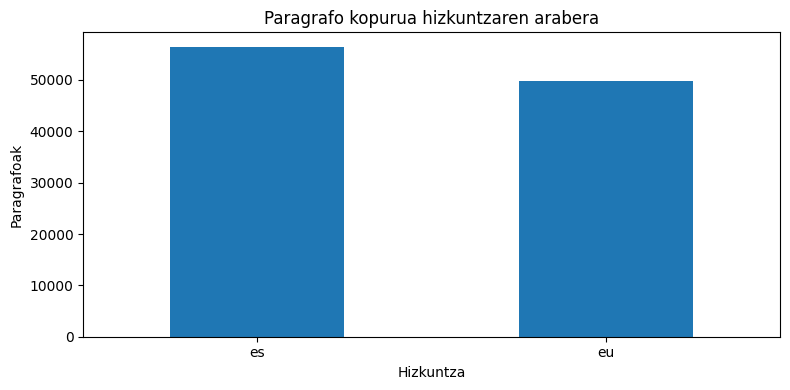

In [7]:
ax = language_stats["paragrafoak"].plot(kind="bar", figsize=(8, 4))
ax.set_title("Paragrafo kopurua hizkuntzaren arabera")
ax.set_xlabel("Hizkuntza")
ax.set_ylabel("Paragrafoak")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_hizkuntzak_paragrafoak.png", dpi=200)
plt.show()


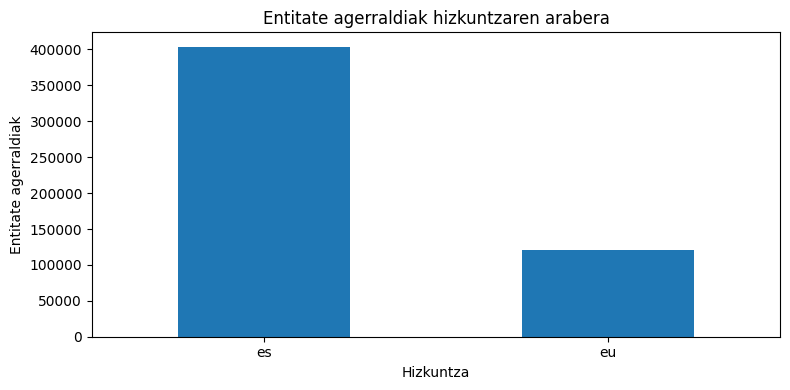

In [8]:
ax = language_stats["entitateak"].plot(kind="bar", figsize=(8, 4))
ax.set_title("Entitate agerraldiak hizkuntzaren arabera")
ax.set_xlabel("Hizkuntza")
ax.set_ylabel("Entitate agerraldiak")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_hizkuntzak_entitateak.png", dpi=200)
plt.show()


## 6. Parte-hartzeak hizlariaren eta alderdiaren arabera

Atal hau erabilgarria da corpusaren osaera soziopolitikoa azaltzeko: nor agertzen den gehien, zer alderditako testuak diren nagusi, eta datuak nola banatzen diren.


In [9]:
speaker_stats = (
    df.groupby("Speaker", dropna=False)
      .agg(
          parte_hartzeak=("speech_key", "nunique"),
          paragrafoak=("paragraph_key", "nunique"),
          hitzak=("n_words", "sum"),
          entitateak=("n_entities", "sum"),
          hizkuntzak=("Language", lambda s: ", ".join(sorted(set(x for x in s if x))))
      )
      .sort_values(["parte_hartzeak", "paragrafoak"], ascending=False)
)

display(speaker_stats.head(20))
speaker_stats.to_csv(OUTPUT_DIR / "03_hizlariak.csv", encoding="utf-8", sep=";")


,parte_hartzeak,paragrafoak,hitzak,entitateak,hizkuntzak
Speaker,,,,,
TejeriaOtermin,337,21142,605268,62888,"es, eu"
BarrioBaroja,217,615,443949,13080,"es, eu"
GarridoKnörr,204,538,427373,11752,"es, eu"
UberaAranzeta,162,435,240794,6012,"es, eu"
HernándezHidalgo,159,384,343554,8148,"es, eu"
CasanovaAlonso,131,354,299126,7933,"es, eu"
LópezDeOcarizLópezDeMunain,129,346,237522,6800,"es, eu"
MartínezZatón,126,277,224020,7576,"es, eu"
UrkulluRenteria,114,889,440982,17569,"es, eu"


In [10]:
party_stats = (
    df.groupby("Party", dropna=False)
      .agg(
          parte_hartzeak=("speech_key", "nunique"),
          paragrafoak=("paragraph_key", "nunique"),
          hizlariak=("Speaker", lambda s: s.replace("", np.nan).nunique()),
          hitzak=("n_words", "sum"),
          entitateak=("n_entities", "sum"),
      )
      .sort_values(["parte_hartzeak", "paragrafoak"], ascending=False)
)

party_stats["entitateak_1000_hitzeko"] = np.where(
    party_stats["hitzak"] > 0,
    (party_stats["entitateak"] / party_stats["hitzak"] * 1000).round(2),
    0
)

display(party_stats.head(20))
party_stats.to_csv(OUTPUT_DIR / "04_alderdiak.csv", encoding="utf-8", sep=";")


,parte_hartzeak,paragrafoak,hizlariak,hitzak,entitateak,entitateak_1000_hitzeko
Party,,,,,,
Euzko Alderdi Jeltzalea,2117,26575,63,3989119,168098,42.14
Euskal Herria Bildu,1484,3363,42,2361197,67851,28.74
Euskadiko Alderdi Sozialista - Euskadiko Ezkerra,1175,2748,28,2237452,58897,26.32
Alderdi Popularra,956,2539,14,1947874,55601,28.54
Elkarrekin Podemos - IU,848,1871,15,1440807,39379,27.33
EAJ,405,24199,50,762234,30867,40.50
EH Bildu,302,11371,29,522656,14855,28.42
PP,265,9901,16,541040,15231,28.15
EP,256,9639,15,471138,12982,27.55


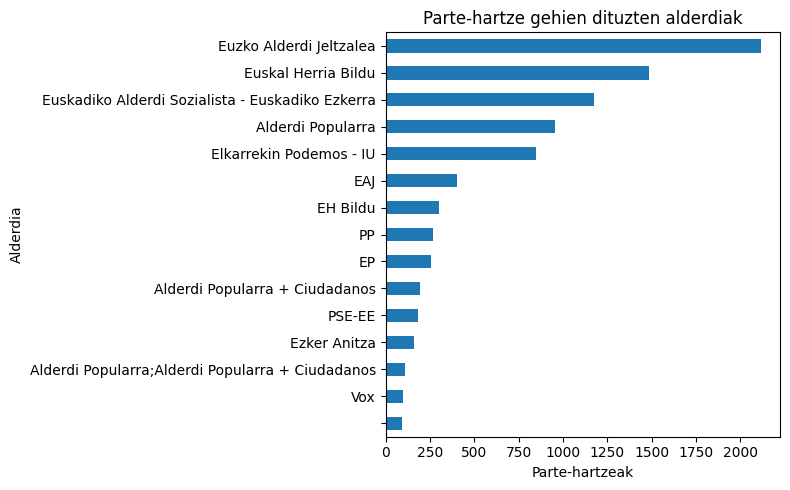

In [11]:
ax = party_stats.head(15)["parte_hartzeak"].sort_values().plot(kind="barh", figsize=(8, 5))
ax.set_title("Parte-hartze gehien dituzten alderdiak")
ax.set_xlabel("Parte-hartzeak")
ax.set_ylabel("Alderdia")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_alderdiak_partehartzeak.png", dpi=200)
plt.show()


## 7. Paragrafo kopuruaren banaketa parte-hartzeko

Banaketa honek erakusten du parte-hartzeak laburrak edo luzeak diren, hau da, diskurtso bakoitza zenbat paragrafo/testu-zatitan banatuta dagoen.


In [13]:
paragraphs_per_speech = (
    df.groupby("speech_key")
      .agg(
          paragrafoak=("paragraph_key", "nunique"),
          hizlaria=("Speaker", "first"),
          alderdia=("Party", "first"),
          hizkuntzak=("Language", lambda s: ", ".join(sorted(set(x for x in s if x)))),
          hitzak=("n_words", "sum"),
          entitateak=("n_entities", "sum"),
      )
      .sort_values("paragrafoak", ascending=False)
)

numeric_summary = paragraphs_per_speech.select_dtypes(include="number").describe().round(2)
display(numeric_summary)
display(paragraphs_per_speech.head(20))
paragraphs_per_speech.to_csv(OUTPUT_DIR / "05_paragrafoak_partehartzeko.csv", encoding="utf-8", sep=";")


,paragrafoak,hitzak,entitateak
count,8761.00,8761.00,8761.00
mean,12.13,1877.00,59.86
std,25.81,1432.24,56.69
min,1.00,1.00,0.00
25%,2.00,772.00,22.00
50%,2.00,1632.00,43.00
75%,6.00,2436.00,78.00
max,357.00,21003.00,846.00


,paragrafoak,hizlaria,alderdia,hizkuntzak,hitzak,entitateak
speech_key,,,,,,
2019-09-20__47__JAURLARITZAKO LEHENDAKARIAK (Urkullu Renteria),357,JAURLARITZAKO LEHENDAKARIAK (Urkullu Renteria),EAJ,"es, eu",15932,639
2018-10-19__10__LEHENDAKARIA,329,LEHENDAKARIA,,"es, eu",9015,384
2015-02-13__6__Tejeria Otermin LEHENDAKARIA,299,Tejeria Otermin LEHENDAKARIA,EAJ,"es, eu",6155,429
2013-12-13__2__Tejeria Otermin LEHENDAKARIA,282,Tejeria Otermin LEHENDAKARIA,EAJ,"es, eu",5219,357
2019-02-07__20__Tejeria Otermin LEHENDAKARIA,261,Tejeria Otermin LEHENDAKARIA,EAJ,"es, eu",4430,292
2019-04-04__33__Tejeria Otermin LEHENDAKARIA,258,Tejeria Otermin LEHENDAKARIA,EAJ,"es, eu",2323,226
2019-11-29__61__Tejeria Otermin LEHENDAKARIA,250,Tejeria Otermin LEHENDAKARIA,EAJ,"es, eu",5532,366
2018-11-29__15__Tejeria Otermin LEHENDAKARIA,248,Tejeria Otermin LEHENDAKARIA,EAJ,"es, eu",2676,269
2019-10-11__51__LEHENDAKARIA,248,LEHENDAKARIA,,"es, eu",4379,284


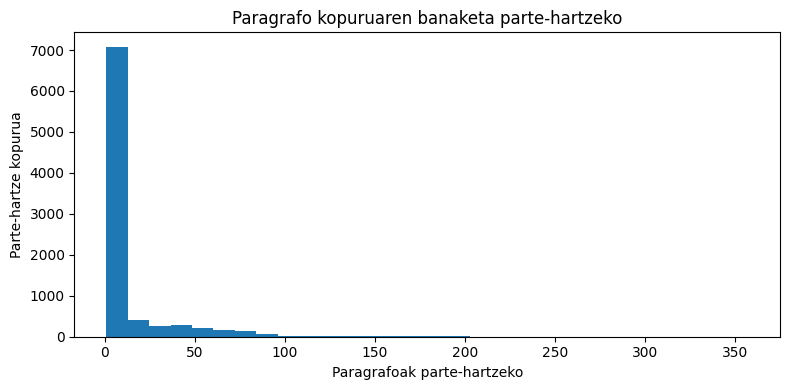

In [14]:
ax = paragraphs_per_speech["paragrafoak"].plot(kind="hist", bins=30, figsize=(8, 4))
ax.set_title("Paragrafo kopuruaren banaketa parte-hartzeko")
ax.set_xlabel("Paragrafoak parte-hartzeko")
ax.set_ylabel("Parte-hartze kopurua")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_paragrafoak_banaketa.png", dpi=200)
plt.show()


## 8. Entitate izendunen analisia

Atal honetan NER neuronalak detektatutako entitateak aztertzen dira: etiketa motak, hizkuntzaren araberako banaketa eta gehien agertzen diren entitateak.


In [15]:
if len(ent_df) > 0:
    entity_label_stats = (
        ent_df.groupby("entity_label", dropna=False)
              .agg(
                  entitate_agerraldiak=("entity_text", "size"),
                  entitate_bakarrak=("entity_text_norm", "nunique"),
              )
              .sort_values("entitate_agerraldiak", ascending=False)
    )
    entity_label_stats["agerraldiak_%"] = (entity_label_stats["entitate_agerraldiak"] / entity_label_stats["entitate_agerraldiak"].sum() * 100).round(2)
    display(entity_label_stats)
    entity_label_stats.to_csv(OUTPUT_DIR / "06_entitate_motak.csv", encoding="utf-8", sep=";")
else:
    entity_label_stats = pd.DataFrame()
    print("Ez dago entitaterik aztertzeko.")


,entitate_agerraldiak,entitate_bakarrak,agerraldiak_%
entity_label,,,
ORG,264687,16725,50.47
PER,106838,7682,20.37
LOC,79703,6279,15.20
MISC,73167,17712,13.95


In [16]:
if len(ent_df) > 0:
    entity_by_language = pd.crosstab(ent_df["Language"], ent_df["entity_label"], margins=True, margins_name="Guztira")
    display(entity_by_language)
    entity_by_language.to_csv(OUTPUT_DIR / "07_entitateak_hizkuntza_eta_motaren_arabera.csv", encoding="utf-8", sep=";")
else:
    entity_by_language = pd.DataFrame()


entity_label,LOC,MISC,ORG,PER,Guztira
Language,,,,,
es,65982,64414,215369,57915,403680
eu,13721,8753,49318,48923,120715
Guztira,79703,73167,264687,106838,524395


In [17]:
if len(ent_df) > 0:
    top_entities = (
        ent_df.groupby(["entity_text_norm", "entity_label"], dropna=False)
              .agg(
                  entitatea=("entity_text", "first"),
                  agerraldiak=("entity_text", "size"),
                  hizkuntzak=("Language", lambda s: ", ".join(sorted(set(x for x in s if x)))),
              )
              .reset_index(drop=True)
              .sort_values("agerraldiak", ascending=False)
    )
    display(top_entities.head(30))
    top_entities.to_csv(OUTPUT_DIR / "08_entitate_ohikoenak.csv", index=False, encoding="utf-8", sep=";")
else:
    top_entities = pd.DataFrame()


,entitatea,agerraldiak,hizkuntzak
22743,Gobierno,27976,"es, eu"
18163,Euskadi,15388,"es, eu"
22914,Gobierno Vasco,14022,"es, eu"
37571,Parlamento,8888,"es, eu"
11361,Cámara,8070,es
14059,EH Bildu,6658,"es, eu"
16691,Estado,5357,"es, eu"
14748,Elkarrekin Podemos,5046,"es, eu"
37703,Partido Popular,4590,"es, eu"
16597,España,3898,"es, eu"


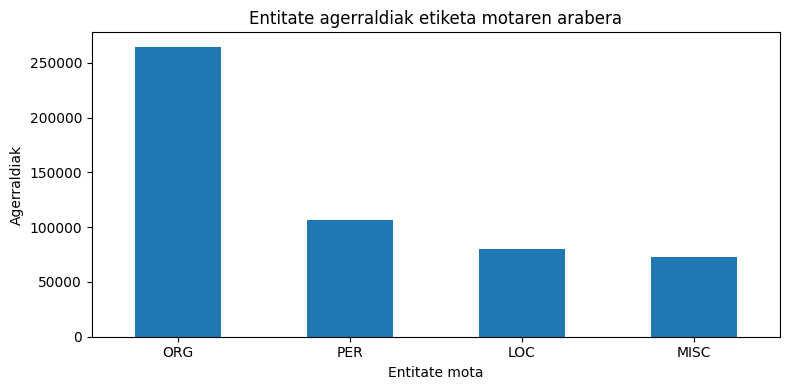

In [18]:
if len(ent_df) > 0:
    ax = entity_label_stats["entitate_agerraldiak"].plot(kind="bar", figsize=(8, 4))
    ax.set_title("Entitate agerraldiak etiketa motaren arabera")
    ax.set_xlabel("Entitate mota")
    ax.set_ylabel("Agerraldiak")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "06_entitate_motak.png", dpi=200)
    plt.show()
